In [49]:
import sys
from pathlib import Path
import torch
from sbi import utils

# Add src/ to sys.path for imports
project_root = Path().resolve().parent 
src_path = project_root / "src"
sys.path.append(str(src_path))

In [3]:
from generator import generate_dataset, generate_observation
from preprocessing import load_dataset, train_val_split, normalize
from train import train_npe
from plots import plot_posterior

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


# 1. Noiseless case

In [50]:
# Simulation dir
save_dir = project_root / "data/simulations"

## Load the TOD simulation and As

In [4]:
theta_path = save_dir / "theta.pt"
x_path = save_dir / "x.pt"

theta, x = load_dataset(theta_path, x_path)

print(f"Theta shape: {theta.shape}")
print(f"X (TOD) shape: {x.shape}") # (num_simulations, num_tod_samples)

Theta shape: torch.Size([2000, 1])
X (TOD) shape: torch.Size([2000, 2000])


## Preprocessing

In [5]:
theta_train, x_train, theta_val, x_val = train_val_split(theta, x)
x_train_norm, x_val_norm, _ = normalize(x_train, x_val)

## Training

In [6]:
prior = utils.BoxUniform(low=torch.tensor([5e-10]), high=torch.tensor([5e-9]))

posterior, density_estimator = train_npe(theta_train, x_train_norm, prior)

/global/homes/b/binguyen/.local/perlmutter/python-3.13/26.1.0/lib/python3.13/site-packages/sbi/neural_nets/net_builders/flow.py:151: UserWarning: In one-dimensional output space, this flow is limited to Gaussians
  x_numel = get_numel(


 Neural network successfully converged after 22 epochs.

## Plots

In [52]:
import matplotlib.pyplot as plt

In [54]:
As = 2.75e-9
x_obs = generate_observation(As, nside=512)

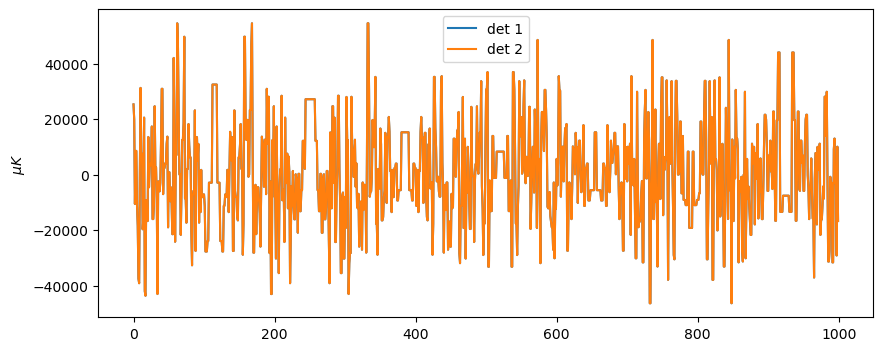

In [63]:
plt.figure(figsize=(10,4))
plt.plot(x_obs[0], label="det 1")
plt.plot(x_obs[1], label="det 2")

plt.ylabel(r"$\mu K$")
plt.legend()
plt.show()

### Test posterior

In [24]:
import numpy as np
import random

  0%|          | 0/10000 [00:00<?, ?it/s]

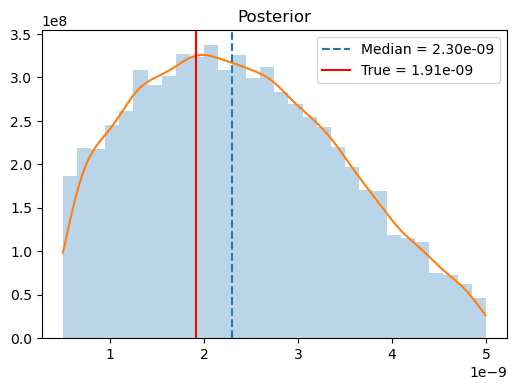

In [44]:
rand_int = random.randint(0, 200)
plot_posterior(posterior, x_val[rand_int:rand_int+1], true_value=theta_val[rand_int].item(), num_samples=10000)

### Coverage test

In [45]:
from diagnostics import compute_sbc
from plots import plot_sbc, plot_coverage

In [46]:
z, med = compute_sbc(posterior, x_val, theta_val)

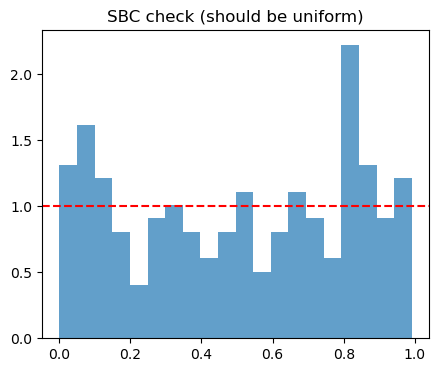

In [47]:
plot_sbc(z)

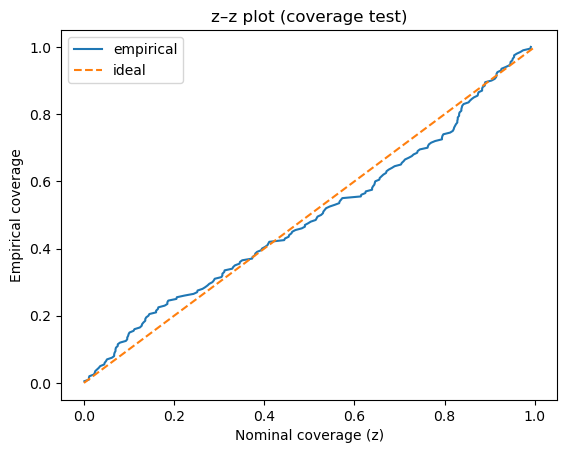

In [48]:
plot_coverage(z)

# 2. Noisy case